# Brazil E-Commerece Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_customers = pd.read_csv("data/olist_customers_dataset.csv")
df_orders = pd.read_csv("data/olist_orders_dataset.csv")
df_payments = pd.read_csv("data/olist_order_payments_dataset.csv")
df_items = pd.read_csv("data/olist_order_items_dataset.csv")
df_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
df_product = pd.read_csv("data/olist_products_dataset.csv")
df_sellers = pd.read_csv("data/olist_sellers_dataset.csv")
df_category_name = pd.read_csv("data/product_category_name_translation.csv")

In [3]:
# Deduplicate Payments: Total up the cash spent per order_id
df_payments_clean = df_payments.groupby('order_id')['payment_value'].sum().reset_index()

In [4]:
# Deduplicate Items: Total up price/freight and count total items per order_id
df_items_clean = df_items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    total_items_qty=('order_item_id', 'count'),
    product_id=('product_id', 'first'), # Keeps the primary product link
    seller_id=('seller_id', 'first')    # Keeps the primary seller link
).reset_index()

In [5]:
# Deduplicate Reviews: If a customer left multiple reviews, take the average score
df_reviews_clean = df_reviews.groupby('order_id')['review_score'].mean().reset_index()

In [6]:
# Join customers to orders
df_oc = pd.merge(df_orders, df_customers, on='customer_id', how='inner')

# Join clean item metrics
df_oci = pd.merge(df_oc, df_items_clean, on='order_id', how='inner')

# Join clean payment metrics (No cash duplication)
df_ocip = pd.merge(df_oci, df_payments_clean, on='order_id', how='inner')

# Join clean reviews (Left join remains intact)
df_ocipr = pd.merge(df_ocip, df_reviews_clean, on='order_id', how='left')

# Join product details, translations, and sellers
df_ociprp = pd.merge(df_ocipr, df_product, on='product_id', how='inner')
df_ociprpc = pd.merge(df_ociprp, df_category_name, on='product_category_name', how='inner')
df_final_olist = pd.merge(df_ociprpc, df_sellers, on='seller_id', how='inner')

print(f"Final combined dataframe shape: {df_final_olist.shape}")

Final combined dataframe shape: (97228, 31)


In [7]:
df = df_final_olist

In [8]:
## View Dataset

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,316.0,4.0,250.0,51.0,15.0,15.0,stationery,8752,mogi das cruzes,SP


Explore the Dataset

In [9]:
df.describe()

,customer_zip_code_prefix,total_price,total_freight,total_items_qty,payment_value,review_score,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix
count,97228.000000,97228.000000,97228.000000,97228.000000,97228.000000,96490.000000,97228.000000,97228.000000,97228.000000,97227.000000,97227.000000,97227.000000,97227.000000,97228.000000
mean,35144.909913,137.890001,22.868484,1.141862,160.787676,4.107733,48.845158,794.166146,2.250463,2108.938762,30.166240,16.516667,23.071606,24685.221634
std,29785.987231,210.533486,21.706396,0.538635,220.399886,1.327887,9.999576,654.790971,1.747086,3769.594437,16.168045,13.348712,11.754923,27750.572135
min,1003.000000,0.850000,0.000000,1.000000,9.590000,1.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000
25%,11380.000000,45.900000,13.860000,1.000000,62.010000,4.000000,42.000000,349.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000
50%,24425.000000,86.900000,17.220000,1.000000,105.280000,5.000000,52.000000,607.000000,2.000000,700.000000,25.000000,13.000000,20.000000,13660.000000
75%,58844.250000,149.900000,24.120000,1.000000,177.412500,5.000000,57.000000,996.000000,3.000000,1813.000000,38.000000,20.000000,30.000000,29156.000000
max,99980.000000,13440.000000,1794.960000,21.000000,13664.080000,5.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97228 entries, 0 to 97227
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       97228 non-null  str    
 1   customer_id                    97228 non-null  str    
 2   order_status                   97228 non-null  str    
 3   order_purchase_timestamp       97228 non-null  str    
 4   order_approved_at              97215 non-null  str    
 5   order_delivered_carrier_date   96252 non-null  str    
 6   order_delivered_customer_date  95097 non-null  str    
 7   order_estimated_delivery_date  97228 non-null  str    
 8   customer_unique_id             97228 non-null  str    
 9   customer_zip_code_prefix       97228 non-null  int64  
 10  customer_city                  97228 non-null  str    
 11  customer_state                 97228 non-null  str    
 12  total_price                    97228 non-null  float64
 1

In [11]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  13
order_delivered_carrier_date      976
order_delivered_customer_date    2131
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
total_price                         0
total_freight                       0
total_items_qty                     0
product_id                          0
seller_id                           0
payment_value                       0
review_score                      738
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    1
product_length_cm                   1
product_height_cm                   1
product_widt

In [12]:
# Convert the order purchase timestamp to a true datetime object
df_final_olist['order_purchase_timestamp'] = pd.to_datetime(df_final_olist['order_purchase_timestamp'])

In [13]:
#  Establish the snapshot date
snapshot_date = df_final_olist['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Dataset Baseline Snapshot Date: {snapshot_date}\n")

Dataset Baseline Snapshot Date: 2018-09-04 09:06:57



In [14]:
#  Aggregate data per unique customer to calculate RFM metrics
df_rfm = df_final_olist.groupby('customer_unique_id').agg(
    # Recency: Days between the customer's latest purchase and our snapshot date
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    
    # Frequency: Total number of unique orders placed by this customer
    Frequency=('order_id', 'nunique'),
    
    # Monetary: Total financial value spent across all their transactions
    Monetary=('payment_value', 'sum')
).reset_index()

In [15]:
#  Inspect your raw RFM matrix
print("=== Raw RFM Dataframe Summary ===")
print(df_rfm.head())
print("\n=== Data Distribution Summary ===")
print(df_rfm[['Recency', 'Frequency', 'Monetary']].describe())

=== Raw RFM Dataframe Summary ===
                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     27.19
2  0000f46a3911fa3c0805444483337064      542          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      326          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      293          1    196.89

=== Data Distribution Summary ===
            Recency     Frequency      Monetary
count  94062.000000  94062.000000  94062.000000
mean     242.894899      1.033659    166.199572
std      153.159198      0.208918    228.226002
min        1.000000      1.000000      9.590000
25%      119.000000      1.000000     63.122500
50%      223.000000      1.000000    107.835000
75%      352.000000      1.000000    183.840000
max      729.000000     15.000000  13664.080000


In [16]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

#  Isolate the raw features for modeling
X_raw = df_rfm[['Recency', 'Frequency', 'Monetary']]

In [17]:
#  Train Isolation Forest to flag the top 3% extreme anomalies
iso_forest = IsolationForest(contamination=0.03, random_state=42)
outlier_flags = iso_forest.fit_predict(X_raw)

In [18]:
# Filter out the outliers (keep rows flagged as 1, drop -1)
df_rfm_clean = df_rfm[outlier_flags == 1].reset_index(drop=True)
print(f"Dropped {len(df_rfm) - len(df_rfm_clean)} outlier accounts.")

Dropped 2822 outlier accounts.


In [19]:
#  Apply StandardScaler to the clean data matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_rfm_clean[['Recency', 'Frequency', 'Monetary']])

In [20]:
# Convert back to a DataFrame for easy handling later
df_scaled = pd.DataFrame(X_scaled, columns=['Recency', 'Frequency', 'Monetary'])

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_scores = []
silhouette_scores = []
k_range = range(2, 7)

# Sample a slice of data for the silhouette score calculation to speed up rendering
sample_scaled = df_scaled.sample(n=10000, random_state=42) if len(df_scaled) > 10000 else df_scaled

In [22]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertia_scores.append(kmeans.inertia_)
    
    # Calculate silhouette score using the sample matrix
    sample_labels = kmeans.predict(sample_scaled)
    silhouette_scores.append(silhouette_score(sample_scaled, sample_labels))

/Users/newowner/Desktop/DS_project/myenv_dsp/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
/Users/newowner/Desktop/DS_project/myenv_dsp/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
/Users/newowner/Desktop/DS_project/myenv_dsp/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
/Users/newowner/Desktop/DS_project/myenv_dsp/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
/Users/newowner/Desktop/DS_project/myenv_dsp/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but KMeans was fitted without feature names
  

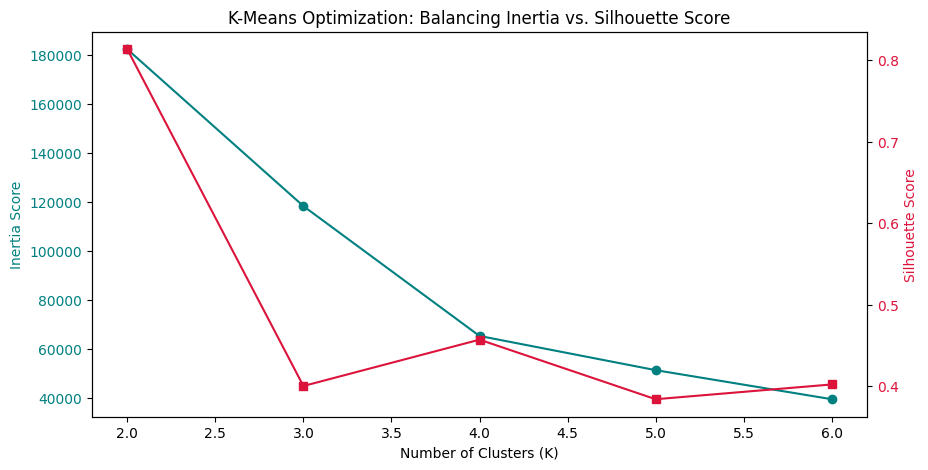

In [23]:
# Plot the evaluation metrics side-by-side
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_range, inertia_scores, color='teal', marker='o', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia Score', color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, color='crimson', marker='s', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('K-Means Optimization: Balancing Inertia vs. Silhouette Score')
plt.show()

In [24]:
from sklearn.cluster import DBSCAN

#  Fit Final K-Means Model (Assuming optimal K=4 based on the optimization chart)
final_kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_rfm_clean['KMeans_Cluster'] = final_kmeans.fit_predict(X_scaled)

In [25]:
#  Fit DBSCAN as a baseline density comparison
dbscan = DBSCAN(eps=0.5, min_samples=15)
df_rfm_clean['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print("=== K-Means Cluster Value Distribution ===")
print(df_rfm_clean['KMeans_Cluster'].value_counts())

print("\n=== DBSCAN Cluster Value Distribution (-1 represents Noise) ===")
print(df_rfm_clean['DBSCAN_Cluster'].value_counts().head())

=== K-Means Cluster Value Distribution ===
KMeans_Cluster
3    47476
1    35149
0     7377
2     1238
Name: count, dtype: int64

=== DBSCAN Cluster Value Distribution (-1 represents Noise) ===
DBSCAN_Cluster
 0    89789
 2     1225
 1      213
-1       13
Name: count, dtype: int64


In [26]:
import plotly.graph_objects as go

# Append cluster assignments back to the scaled data to get the true scaled averages
df_scaled['Cluster'] = df_rfm_clean['KMeans_Cluster']
cluster_summary = df_scaled.groupby('Cluster').mean().reset_index()

categories = ['Recency', 'Frequency', 'Monetary']

fig = go.Figure()

# Map out a colored vector tracing each consumer profile
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']

for i in range(len(cluster_summary)):
    fig.add_trace(go.Scatterpolar(
        r=[cluster_summary.loc[i, 'Recency'], cluster_summary.loc[i, 'Frequency'], cluster_summary.loc[i, 'Monetary']],
        theta=categories,
        fill='toself',
        name=f'Cluster {i}',
        line=dict(color=colors[i])
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[df_scaled[categories].min().min(), df_scaled[categories].max().max()])),
    showlegend=True,
    title="Enterprise Customer Persona Matrix (Scaled RFM Profile per Cluster)"
)
fig.show()

In [27]:
import plotly.express as px

#  Compute shipping delays using the raw parent dataframe
df_final_olist['order_delivered_customer_date'] = pd.to_datetime(df_final_olist['order_delivered_customer_date'])
df_final_olist['order_estimated_delivery_date'] = pd.to_datetime(df_final_olist['order_estimated_delivery_date'])

In [28]:
# Positive values mean it arrived early; negative values show actual delivery delays
df_final_olist['delivery_delta_days'] = (df_final_olist['order_estimated_delivery_date'] - df_final_olist['order_delivered_customer_date']).dt.days

In [29]:
#  Group performance profiles by Brazilian customer state
geo_latency = df_final_olist.groupby('customer_state').agg(
    avg_latency_days=('delivery_delta_days', 'mean'),
    avg_review_score=('review_score', 'mean'),
    total_orders=('order_id', 'count')
).reset_index()

In [30]:
#  Build a spatial scatter map tracking localized friction points
fig = px.scatter(
    geo_latency,
    x="avg_latency_days",
    y="avg_review_score",
    size="total_orders",
    color="avg_latency_days",
    text="customer_state",
    color_continuous_scale=px.colors.sequential.Viridis,
    title="Logistical Friction Analysis: Customer Sentiment vs. Delivery Performance by State"
)

fig.update_traces(textposition='top center')
fig.update_layout(xaxis_title="Average Days Ahead of Estimated Schedule", yaxis_title="Average Review Rating (1-5)")
fig.show()

In [31]:
# kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
# cluster_labels = kmeans.fit_predict(X_scaled)

# inertia_scores.append(kmeans.inertia_)

In [32]:
# silhouette_scores.append(silhouette_score(sample_scaled, sample_labels))

In [33]:
print(inertia_scores)

[182195.75540731242, 118305.2692157421, 65420.518785341505, 51494.313851431674, 39653.800943211754]


In [34]:
print(silhouette_scores)

[0.8136089456166204, 0.40035362879207953, 0.45722504301164024, 0.3841317360126234, 0.4022658662566004]
